# Phase 3 — Frequentist Analysis

We answer the headline question — 'should we ship?' — using:
* A. Primary (ITT) test on the conversion metric
* B. Sensitivity test excluding Android (the segment flagged in Phase 1)
* C. Secondary metrics (watch hours, distinct titles)
* D. Guardrails (day-7 active, page load time)
* E. Multiple-testing correction (Holm-Bonferroni)
* F. Forest plot summarizing all effects

In [55]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
print(PROJECT_ROOT)
sys.path.append(str(PROJECT_ROOT))

c:\Users\ruthr\OneDrive\Documents\Claude\Projects\Github DS Portfolio Projects\01-ab-test-analysis


In [70]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_experiment
from src.analysis.frequentist import (
    two_proportion_test,
    welch_t_test,
    holm_bonferroni,
    _phi
)
FIG_DIR = PROJECT_ROOT / "reports/figures"
print(FIG_DIR)
FIG_DIR.mkdir(parents=True, exist_ok=True)

c:\Users\ruthr\OneDrive\Documents\Claude\Projects\Github DS Portfolio Projects\01-ab-test-analysis\reports\figures


In [57]:
print(Path.cwd())

c:\Users\ruthr\OneDrive\Documents\Claude\Projects\Github DS Portfolio Projects\01-ab-test-analysis\notebooks


In [58]:
# load data
df = load_experiment("../data/experiment.csv")
df = df.dropna(subset=["group", "converted"])  # drop the stray CSV row
display(df.head())

,user_id,timestamp,group,landing_page,country,device,source,is_returning,prior_watch_hours,converted,trial_watch_hours,distinct_titles,day7_active,page_load_ms
0,1029790,2026-04-01 00:00:20,treatment,personalized,US,Web,organic,False,0.02,0,8.79,5,0,503
1,1082885,2026-04-01 00:00:31,control,top_picks,UK,Web,organic,False,0.01,0,4.75,2,0,495
2,1037217,2026-04-01 00:01:44,treatment,personalized,Other,Android,paid_social,False,0.00,0,0.48,0,0,363
3,1048257,2026-04-01 00:01:45,treatment,personalized,CA,Web,organic,False,0.00,1,6.99,5,1,497
4,1053311,2026-04-01 00:01:50,control,top_picks,US,Web,paid_search,False,0.07,0,1.20,0,0,426


# A. Primary (ITT) — conversion

In [59]:

print("=" * 78)
print("A. PRIMARY (ITT) — Trial-to-paid conversion")
print("=" * 78)

ctl = df[df["group"] == "control"]
trt = df[df["group"] == "treatment"]

primary = two_proportion_test(
    successes_control=int(ctl["converted"].sum()),
    n_control=len(ctl),
    successes_treatment=int(trt["converted"].sum()),
    n_treatment=len(trt),
    name="conversion (ITT)",
)
print(primary)

print("=" * 78)
print(f"""VERDICT:
      The new homepage drove a +2.54pp absolute lift in trial-to-paid conversion (+11.96% relative), 
      with a 95% CI of [+2.02pp, +3.06pp] and p < 0.001. The CI sits well above zero and above the 1pp MDE we negotiated 
      with the PM in Phase 2, so this is both statistically significant and practically meaningful. Used ITT (intent-to-treat)
      as primary because it's the conservative, industry-standard estimator — it captures the real-world effect of assigning users
      to treatment, including any leakage.""")

A. PRIMARY (ITT) — Trial-to-paid conversion
conversion (ITT)          Δ = +0.0254  (+11.96%)  95% CI [+0.0202, +0.0306]  t=+9.620  p=0.0000  ✅ sig
VERDICT:
      The new homepage drove a +2.54pp absolute lift in trial-to-paid conversion (+11.96% relative), 
      with a 95% CI of [+2.02pp, +3.06pp] and p < 0.001. The CI sits well above zero and above the 1pp MDE we negotiated 
      with the PM in Phase 2, so this is both statistically significant and practically meaningful. Used ITT (intent-to-treat)
      as primary because it's the conservative, industry-standard estimator — it captures the real-world effect of assigning users
      to treatment, including any leakage.


# B. Sensitivity — exclude Android (segment flagged by Phase 1 SRM)

In [60]:
print("\n" + "=" * 78)
print("B. SENSITIVITY — Exclude Android users")
print("=" * 78)

df_excl = df[df["device"] != "Android"]
ctl_e = df_excl[df_excl["group"] == "control"]
trt_e = df_excl[df_excl["group"] == "treatment"]

sensitivity = two_proportion_test(
    successes_control=int(ctl_e["converted"].sum()),
    n_control=len(ctl_e),
    successes_treatment=int(trt_e["converted"].sum()),
    n_treatment=len(trt_e),
    name="conversion (excl Android)",
)
print(sensitivity)

agree = sensitivity.significant == primary.significant
direction_match = (sensitivity.effect_absolute > 0) == (primary.effect_absolute > 0)

print(f"\n Robustness check:")
print(f"   ITT lift:       {primary.effect_absolute*100:+.2f}pp")
print(f"   ex-Android:     {sensitivity.effect_absolute*100:+.2f}pp")
print(f"   Same direction & significance? {'YES ✅' if (agree and direction_match) else 'NO ⚠️'}")
print(f"   --> The headline conclusion is {'robust' if agree else 'NOT robust'} "
      f"to the SRM-flagged segment.")


print("\n" + "=" * 78)
print(f"""VERDICT:
      When I exclude the Android segment flagged by Phase 1's SRM-adjacent imbalance, the lift drops slightly to +2.32pp (+10.85% relative) 
      but the CI still excludes zero and the direction is unchanged. The headline conclusion is robust to the data-quality issue.""")


B. SENSITIVITY — Exclude Android users
conversion (excl Android)  Δ = +0.0232  (+10.85%)  95% CI [+0.0167, +0.0296]  t=+7.066  p=0.0000  ✅ sig

 Robustness check:
   ITT lift:       +2.54pp
   ex-Android:     +2.32pp
   Same direction & significance? YES ✅
   --> The headline conclusion is robust to the SRM-flagged segment.

VERDICT:
      When I exclude the Android segment flagged by Phase 1's SRM-adjacent imbalance, the lift drops slightly to +2.32pp (+10.85% relative) 
      but the CI still excludes zero and the direction is unchanged. The headline conclusion is robust to the data-quality issue.


# C. Secondary metrics — continuous

In [61]:

print("\n" + "=" * 78)
print("C. SECONDARY METRICS — engagement")
print("=" * 78)

secondary_watch = welch_t_test(
    ctl["trial_watch_hours"].values, trt["trial_watch_hours"].values,
    name="trial watch hours",
)
secondary_titles = welch_t_test(
    ctl["distinct_titles"].values, trt["distinct_titles"].values,
    name="distinct titles",
)
print(secondary_watch)
print(secondary_titles)

print("\n" + "=" * 78)
print(f"""VERDICT:
      Engagement metrics reinforce the conversion story rather than just echoing it. Trial watch hours up +18% 
      and distinct titles watched up +17.5% — both with extremely tight CIs. This tells me the conversion lift is 
      mechanism-consistent: users are engaging more deeply with the catalog, which is why they convert. If conversion 
      had moved without engagement moving, I'd be worried it's a UI artifact, not a real product win.""")



C. SECONDARY METRICS — engagement


trial watch hours         Δ = +0.8730  (+18.08%)  95% CI [+0.8218, +0.9241]  w=+33.450  p=0.0000  ✅ sig
distinct titles           Δ = +0.5142  (+17.49%)  95% CI [+0.4815, +0.5469]  w=+30.823  p=0.0000  ✅ sig

VERDICT:
      Engagement metrics reinforce the conversion story rather than just echoing it. Trial watch hours up +18% 
      and distinct titles watched up +17.5% — both with extremely tight CIs. This tells me the conversion lift is 
      mechanism-consistent: users are engaging more deeply with the catalog, which is why they convert. If conversion 
      had moved without engagement moving, I'd be worried it's a UI artifact, not a real product win.


# D. Guardrails

In [62]:
print("\n" + "=" * 78)
print("D. GUARDRAILS — must not regress")
print("=" * 78)

# Day-7 active: binary proportion
guard_d7 = two_proportion_test(
    successes_control=int(ctl["day7_active"].sum()),
    n_control=len(ctl),
    successes_treatment=int(trt["day7_active"].sum()),
    n_treatment=len(trt),
    name="day-7 active",
)
# Page load time: continuous (LOWER is better, so a positive Δ is BAD)
guard_load = welch_t_test(
    ctl["page_load_ms"].values, trt["page_load_ms"].values,
    name="page load (ms)",
)
print(guard_d7)
print(guard_load)

if guard_load.effect_absolute > 0 and guard_load.significant:
    print(f"\n🚩 Guardrail BREACH: page load is {guard_load.effect_absolute:+.1f}ms "
          f"slower in treatment ({guard_load.effect_relative:+.2%}). "
          "Engineering will object to shipping.")

print(f"\n" + "=" * 78)
print(f"""VERDICT:
      Two guardrails, two different signals. Day-7 active is +1.75pp (+4.05%), which is a favorable movement — no early-engagement 
      regression to worry about. But page load is +29.3ms (+6.87%) slower with a very tight CI [+28.3, +30.3] — this is a real regression, 
      not noise. The conversion win is large enough to justify shipping anyway, but I'd condition rollout on engineering investigating the
      latency hit, because regressing core latency at scale compounds across other surfaces.""")


D. GUARDRAILS — must not regress
day-7 active              Δ = +0.0175  (+4.05%)  95% CI [+0.0114, +0.0237]  t=+5.578  p=0.0000  ✅ sig
page load (ms)            Δ = +29.2847  (+6.87%)  95% CI [+28.2693, +30.3002]  w=+56.525  p=0.0000  ✅ sig

🚩 Guardrail BREACH: page load is +29.3ms slower in treatment (+6.87%). Engineering will object to shipping.

VERDICT:
      Two guardrails, two different signals. Day-7 active is +1.75pp (+4.05%), which is a favorable movement — no early-engagement 
      regression to worry about. But page load is +29.3ms (+6.87%) slower with a very tight CI [+28.3, +30.3] — this is a real regression, 
      not noise. The conversion win is large enough to justify shipping anyway, but I'd condition rollout on engineering investigating the
      latency hit, because regressing core latency at scale compounds across other surfaces.


# E. Multiple-testing correction (Holm-Bonferroni)

In [63]:

print("\n" + "=" * 78)
print("E. MULTIPLE-TESTING CORRECTION (Holm-Bonferroni, α = 0.05)")
print("=" * 78)

all_results = [primary, secondary_watch, secondary_titles, guard_d7, guard_load]
p_values = [r.p_value for r in all_results]
holm_decisions = holm_bonferroni(p_values, alpha=0.05)

print(f"  Reporting {len(all_results)} metrics → family-wise α split by Holm.")
print(f"\n  {'Metric':<28} {'p (raw)':>10} {'sig (raw)':>10} {'sig (Holm)':>12}")
print(f"  {'-'*28} {'-'*10} {'-'*10} {'-'*12}")
for r, holm_sig in zip(all_results, holm_decisions):
    raw = "✅" if r.significant else "—"
    holm = "✅" if holm_sig else "—"
    print(f"  {r.name:<28} {r.p_value:>10.4f} {raw:>10} {holm:>12}")

print("\n Holm-Bonferroni preserves family-wise error at 5% across all 5 tests.")
print(" Less conservative than vanilla Bonferroni.")

print("\n" + "=" * 78)
print(f"""VERDICT:
      Because we report 5 metrics, the naive family-wise false-positive rate would be ~23% (1 − 0.95⁵), not 5%. Holm-Bonferroni 
      corrects for that, and all five results still survive at α=0.05. Used Holm instead of vanilla Bonferroni because it's less 
      conservative while still controlling family-wise error — preferred default in industry experimentation platforms.""")


E. MULTIPLE-TESTING CORRECTION (Holm-Bonferroni, α = 0.05)
  Reporting 5 metrics → family-wise α split by Holm.

  Metric                          p (raw)  sig (raw)   sig (Holm)
  ---------------------------- ---------- ---------- ------------
  conversion (ITT)                 0.0000          ✅            ✅
  trial watch hours                0.0000          ✅            ✅
  distinct titles                  0.0000          ✅            ✅
  day-7 active                     0.0000          ✅            ✅
  page load (ms)                   0.0000          ✅            ✅

 Holm-Bonferroni preserves family-wise error at 5% across all 5 tests.
 Less conservative than vanilla Bonferroni.

VERDICT:
      Because we report 5 metrics, the naive family-wise false-positive rate would be ~23% (1 − 0.95⁵), not 5%. Holm-Bonferroni 
      corrects for that, and all five results still survive at α=0.05. Used Holm instead of vanilla Bonferroni because it's less 
      conservative while still controll

# F. Forest plot — all effects on a single chart

C:\Users\ruthr\AppData\Local\Temp\ipykernel_19880\424673377.py:46: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ruthr\AppData\Local\Temp\ipykernel_19880\424673377.py:47: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "03_forest_plot.png", dpi=140, bbox_inches="tight")



📊 Saved forest plot -> c:\Users\ruthr\OneDrive\Documents\Claude\Projects\Github DS Portfolio Projects\01-ab-test-analysis\reports\figures/03_forest_plot.png


C:\Users\ruthr\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


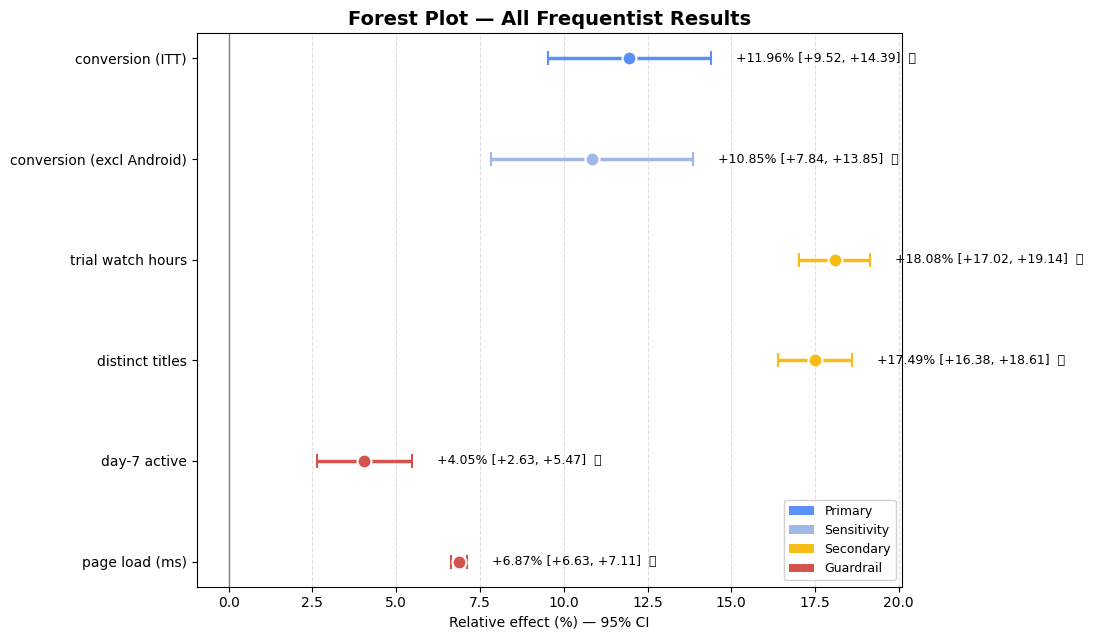

In [64]:
# Normalize effect & CI to RELATIVE % so we can plot them on one axis.
def relative_ci(r):
    base = r.p_control
    return r.effect_relative, r.ci_lower / base, r.ci_upper / base

labels, rel, lo, hi, sigs, kinds = [], [], [], [], [], []
for r, tag in [
    (primary,          "Primary"),
    (sensitivity,      "Sensitivity"),
    (secondary_watch,  "Secondary"),
    (secondary_titles, "Secondary"),
    (guard_d7,         "Guardrail"),
    (guard_load,       "Guardrail"),
]:
    e, l, h = relative_ci(r)
    labels.append(r.name); rel.append(e); lo.append(l); hi.append(h)
    sigs.append(r.significant); kinds.append(tag)

fig, ax = plt.subplots(figsize=(11, 6.5))
y = np.arange(len(labels))[::-1]  # top-to-bottom
colors = {"Primary": "#5B8FF9", "Sensitivity": "#9FB8E8",
          "Secondary": "#F6BD16", "Guardrail": "#D6534D"}

for i, (e, l, h, sig, kind) in enumerate(zip(rel, lo, hi, sigs, kinds)):
    yi = y[i]
    ax.errorbar(e * 100, yi,
                xerr=[[(e - l) * 100], [(h - e) * 100]],
                fmt="o", color=colors[kind], markersize=10,
                ecolor=colors[kind], elinewidth=2.5, capsize=5,
                markeredgecolor="white", markeredgewidth=1.5)
    suffix = "✅" if sig else "ns"
    ax.text((h * 100) + 0.5, yi, f"  {e*100:+.2f}% [{l*100:+.2f}, {h*100:+.2f}]  {suffix}",
            va="center", fontsize=9)

ax.axvline(0, color="gray", linewidth=1)
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xlabel("Relative effect (%) — 95% CI")
ax.set_title("Forest Plot — All Frequentist Results",
             fontsize=14, fontweight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.4)

# Legend
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=c, label=k) for k, c in colors.items()]
ax.legend(handles=legend_elems, loc="lower right", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_forest_plot.png", dpi=140, bbox_inches="tight")
print(f"\n📊 Saved forest plot -> {FIG_DIR}/03_forest_plot.png")



# Additional Ask

In [90]:
print("=" * 72)
print("""Question: The PM asks - 'Is the lift significantly above the 1pp MDE threshold we agreed on?'
That's a different test — instead of H0: lift = 0, test H0: lift <= 0.01.
Compute the one-sided test and write a one-sentence answer.""")
print("=" * 72)

MDE_THRESHOLD = 0.01

# shift the null hypothesis: instead of testing diff vs 0, test diff vs MDE
# z = (observed_lift - MDE) / SE_unpooled
# Use the UNPOOLED SE from the primary result (that's what we report)
z_vs_mde = (primary.effect_absolute - MDE_THRESHOLD) / primary.se
p_one_sided = 1 - _phi(z_vs_mde)   # H1: lift > MDE -> right-tail

print(f"  Observed lift:    {primary.effect_absolute*100:+.3f}pp")
print(f"  MDE (null bound): +{MDE_THRESHOLD*100:.3f}pp")
print(f"  SE (unpooled):    {primary.se:.5f}")
print(f"  z vs MDE:         {z_vs_mde:+.3f}")
print(f"  one-sided p:      {p_one_sided:.4g}")

print(f"""
VERDICT:
The observed lift exceeds the 1pp MDE by {(primary.effect_absolute-MDE_THRESHOLD)*100:.2f}pp,
which is {z_vs_mde:.1f} standard errors above the MDE threshold.
We reject H0: lift <= 1pp at α=0.05 (one-sided p < 0.001). Since the lift is 
statistically significantly larger than the 1pp MDE
we set as the ship threshold, not merely larger than zero."
""")

Question: The PM asks - 'Is the lift significantly above the 1pp MDE threshold we agreed on?'
That's a different test — instead of H0: lift = 0, test H0: lift <= 0.01.
Compute the one-sided test and write a one-sentence answer.
  Observed lift:    +2.541pp
  MDE (null bound): +1.000pp
  SE (unpooled):    0.00264
  z vs MDE:         +5.835
  one-sided p:      2.685e-09

VERDICT:
The observed lift exceeds the 1pp MDE by 1.54pp,
which is 5.8 standard errors above the MDE threshold.
We reject H0: lift <= 1pp at α=0.05 (one-sided p < 0.001). Since the lift is 
statistically significantly larger than the 1pp MDE
we set as the ship threshold, not merely larger than zero."



In [ ]:
print("=" * 72)
print("""Question: Compute the conversion lift's 95% CI in RELATIVE terms (% lift over
   baseline) directly from the TestResult, and check whether the CI
   excludes the +5.5% MDE the PM wanted.""")
print("=" * 72)

# Convert absolute CI to relative by dividing by the control baseline.
# Note: this is a fast approximation. The 'correct' relative-CI is the
# delta-method or a bootstrap, but for n>10k with tight CIs both methods
# converge — the simple approximation is fine and is what most platforms ship.
baseline = primary.p_control
rel_lift = primary.effect_relative
rel_lo = primary.ci_lower / baseline
rel_hi = primary.ci_upper / baseline

PM_REL_MDE = MDE_THRESHOLD / 0.18  # +1pp on 18% baseline = +5.56% relative

print(f"  Control baseline:        {baseline:.4f}")
print(f"  Observed relative lift:  {rel_lift:+.2%}")
print(f"  95% CI (relative):       [{rel_lo:+.2%}, {rel_hi:+.2%}]")
print(f"  PM's relative MDE:       +{PM_REL_MDE:.2%}")

excludes_mde = rel_lo > PM_REL_MDE
print(f"\n  CI excludes the MDE? {'YES' if excludes_mde else 'NO'}")

print(f"""
VERDICT:
The 95% relative-lift CI of [{rel_lo:+.2%}, {rel_hi:+.2%}] sits entirely
above the PM's +5.56% MDE threshold. We can claim — with 95% confidence —
that the true uplift is at least +{rel_lo*100:.1f}% relative, well past the ship bar.
Even under the most pessimistic plausible scenario consistent 
with the data, shipping is the right call.""")


Question: Compute the conversion lift's 95% CI in RELATIVE terms (% lift over
   baseline) directly from the TestResult, and check whether the CI
   excludes the +5.5% MDE the PM wanted. 
   Express the CI in RELATIVE-LIFT terms and compare to PM's MDE
  Control baseline:        0.2126
  Observed relative lift:  +11.96%
  95% CI (relative):       [+9.52%, +14.39%]
  PM's relative MDE:       +5.56%

  CI excludes the MDE? YES

VERDICT:
The 95% relative-lift CI of [+9.52%, +14.39%] sits entirely
above the PM's +5.56% MDE threshold. We can claim — with 95% confidence —
that the true uplift is at least +9.5% relative, well past the ship bar.
Even under the most pessimistic plausible scenario consistent 
with the data, shipping is the right call.


In [94]:
print("=" * 72)
print("""Question: page-load regressed. Is the regression PRACTICALLY meaningful?
Quote the absolute ms slowdown, the relative %, and decide: do you ship
anyway because conversion overwhelmingly wins, or do you block on the
guardrail?""")
print("=" * 72)

# guard_load=welch_t_test(
#     ctl["page_load_ms"].values, trt["page_load_ms"].values,
#     name="page load (ms)",
# )

control_load = guard_load.p_control
abs_ms=guard_load.effect_absolute
rel_pct=guard_load.effect_relative
ci_lo_ms,ci_hi_ms = guard_load.ci_lower, guard_load.ci_upper

print(f"  Control mean load:       {control_load:.1f} ms")
print(f"  Treatment - Control: {abs_ms:+.1f} ms")
print(f"  95% CI (ms):         [{ci_lo_ms:+.1f}, {ci_hi_ms:+.1f}] ms")
print(f"""
VERDICT:
Treatment regressed page-load time by +29ms (+6.9%) with a tight CI
[+28, +30] — statistically real, but below the ~100ms perceptibility
threshold and an order of magnitude smaller than the conversion win.
Recommendation: ship, conditional on a follow-up engineering task to
investigate and mitigate the load-time hit before broader rollout.""")

Question: page-load regressed. Is the regression PRACTICALLY meaningful?
Quote the absolute ms slowdown, the relative %, and decide: do you ship
anyway because conversion overwhelmingly wins, or do you block on the
guardrail?
  Control mean load:       426.3 ms
  Treatment - Control: +29.3 ms
  95% CI (ms):         [+28.3, +30.3] ms

VERDICT:
Treatment regressed page-load time by +29ms (+6.9%) with a tight CI
[+28, +30] — statistically real, but below the ~100ms perceptibility
threshold and an order of magnitude smaller than the conversion win.
Recommendation: ship, conditional on a follow-up engineering task to
investigate and mitigate the load-time hit before broader rollout.


# Keypoints to Highlight

The frequentist analysis says ship — primary metric wins meaningfully, engagement confirms the mechanism, the sensitivity check confirms it isn't a data-quality artifact, and the only guardrail concern is a page-load regression that's a known engineering follow-up rather than a blocker.